In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math

##### 1.定义我们的创新优化器*Critically Damped Adam*

In [18]:
class CriticallyDampedAdam(optim.Optimizer):
    """
    受机械临界阻尼启发的自适应优化器。
    核心逻辑：根据梯度方向的稳定性动态调整动量衰减率 (beta1)。
    - 梯度震荡大 -> 增加阻尼 (减小beta1) -> 抑制振荡
    - 梯度稳定 -> 减小阻尼 (增大beta1) -> 加速收敛
    """
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8, weight_decay=0):
        if not 0.0 <= lr:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if not 0.0 <= eps:
            raise ValueError("Invalid epsilon value: {}".format(eps))
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError("Invalid beta parameter at index 0: {}".format(betas[0]))
        
        defaults = dict(lr=lr, betas=betas, eps=eps, weight_decay=weight_decay)
        super(CriticallyDampedAdam, self).__init__(params, defaults)
        
        # 用于存储上一轮的梯度符号，用于检测震荡
        self.prev_grad_signs = {} 

    def step(self, closure=None):
        loss = None
        if closure is not None:
            loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None:
                    continue
                
                grad = p.grad.data
                if grad.is_sparse:
                    raise RuntimeError('CriticalDampedAdam does not support sparse gradients')
                
                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['step'] = 0
                    state['exp_avg'] = torch.zeros_like(p.data)
                    state['exp_avg_sq'] = torch.zeros_like(p.data)
                    # 初始化上一轮梯度符号
                    self.prev_grad_signs[id(p)] = torch.sign(grad)

                state['step'] += 1
                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                beta1_base, beta2 = group['betas']

                # --- 【核心创新点】：动态计算 beta1 (阻尼系数) ---
                prev_sign = self.prev_grad_signs[id(p)]
                curr_sign = torch.sign(grad)
                
                # 计算符号翻转的比例 (Flip Rate)
                # 如果符号变了，说明在震荡；没变，说明方向一致
                flips = (prev_sign != curr_sign).float().mean().item()
                
                # 物理映射：
                # flips 高 (震荡) -> beta1 应该变小 (阻尼大)
                # flips 低 (稳定) -> beta1 应该变大 (阻尼小，利用惯性)
                # 这里用一个简单的线性映射，实际论文中可以设计更复杂的函数
                # 限制 beta1 在 [0.5, 0.99] 之间，防止极端情况
                dynamic_beta1 = max(0.5, min(0.99, beta1_base - 0.4 * flips))
                
                # 更新保存当前符号供下一轮使用
                self.prev_grad_signs[id(p)] = curr_sign
                # ---------------------------------------------

                bias_correction1 = 1 - dynamic_beta1 ** state['step']
                bias_correction2 = 1 - beta2 ** state['step']

                # 更新一阶矩估计 (使用动态 beta1)
                exp_avg.mul_(dynamic_beta1).add_(grad, alpha=1 - dynamic_beta1)
                # 更新二阶矩估计 (beta2 保持固定，或也可动态)
                exp_avg_sq.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)

                denom = (exp_avg_sq.sqrt() / math.sqrt(bias_correction2)).add_(group['eps'])
                step_size = group['lr'] / bias_correction1

                p.data.addcdiv_(exp_avg, denom, value=-step_size)

                # 权重衰减 (可选)
                if group['weight_decay'] != 0:
                    p.data.add_(p.data, alpha=-group['lr'] * group['weight_decay'])

        return loss

##### 2.定义一个简单的*CNN*模型用于*CIFAR-10*

In [19]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 64 * 8 * 8)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

class CIFAR_AlexNet(nn.Module):
    '''专为CIFAR-10优化的轻量级AlexNet，速度提升5-10倍'''
    def __init__(self, num_classes=10):
        super(CIFAR_AlexNet, self).__init__()
        # 为32x32输入优化
        self.features = nn.Sequential(
            # 输入: [batch, 3, 32, 32]
            nn.Conv2d(3, 64, kernel_size=5, stride=1, padding=2),  # 减小kernel_size
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> [batch, 64, 16, 16]
            
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> [batch, 192, 8, 8]
            
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),  # -> [batch, 384, 8, 8]
            
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),  # -> [batch, 256, 8, 8]
            
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> [batch, 256, 4, 4]
        )
        
        # 自适应池化到固定大小
        self.avgpool = nn.AdaptiveAvgPool2d((4, 4))  # 4x4 而不是 6x6
        
        # 大幅简化的全连接层
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 512),  # 4096 -> 512
            nn.ReLU(inplace=True),
            
            nn.Dropout(0.5),
            nn.Linear(512, 256),  # 4096 -> 256
            nn.ReLU(inplace=True),
            
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

##### 3.训练与评估函数

In [20]:
def train_and_plot():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # 数据准备
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, 4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    
    # 为了演示效果明显，我们只用部分数据或减少Epoch，实际研究请用全量
    trainset = torchvision.datasets.CIFAR10(root=r'E:\mastercode\data', train=True, download=True, transform=transform)
    trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
    
    testset = torchvision.datasets.CIFAR10(root=r'E:\mastercode\data', train=False, download=True, transform=transforms.ToTensor())
    testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

    epochs = 50  # 演示用10个epoch，足够看出趋势
    
    results = {
        'Adam': {'loss': [], 'acc': []},
        'CDA (Ours)': {'loss': [], 'acc': []}
    }

    optimizers_config = [
        ("Adam", optim.Adam),
        ("CDA (Ours)", CriticallyDampedAdam)
    ]

    for opt_name, opt_class in optimizers_config:
        print(f"\n--- Training with {opt_name} ---")
        model = CIFAR_AlexNet(num_classes=10).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = opt_class(model.parameters(), lr=0.001) # 学习率设为0.001

        for epoch in range(epochs):
            running_loss = 0.0
            correct = 0
            total = 0
            
            model.train()
            for i, data in enumerate(trainloader, 0):
                inputs, labels = data[0].to(device), data[1].to(device)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            avg_loss = running_loss / len(trainloader)
            acc = 100 * correct / total
            
            results[opt_name]['loss'].append(avg_loss)
            results[opt_name]['acc'].append(acc)
            
            print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Acc={acc:.2f}%")

    # 4. 绘图对比
    plt.figure(figsize=(12, 5))
    # Loss 曲线
    plt.subplot(1, 2, 1)
    plt.plot(results['Adam']['loss'], label='Standard Adam', marker='o', linestyle='-')
    plt.plot(results['CDA (Ours)']['loss'], label='CriticallyDampedAdam (Ours)', marker='s', linestyle='--')
    plt.title('Training Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy 曲线
    plt.subplot(1, 2, 2)
    plt.plot(results['Adam']['acc'], label='Standard Adam', marker='o', linestyle='-')
    plt.plot(results['CDA (Ours)']['acc'], label='CriticallyDampedAdam (Ours)', marker='s', linestyle='--')
    plt.title('Training Accuracy Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('optimization_comparison.png')
    print("\nPlot saved as 'optimization_comparison.png'")
    plt.show()


Using device: cuda
Files already downloaded and verified
Files already downloaded and verified

--- Training with Adam ---
Epoch 1: Loss=1.8314, Acc=30.43%
Epoch 2: Loss=1.4470, Acc=46.80%
Epoch 3: Loss=1.2657, Acc=54.85%
Epoch 4: Loss=1.1276, Acc=60.11%
Epoch 5: Loss=1.0338, Acc=63.86%
Epoch 6: Loss=0.9575, Acc=66.78%
Epoch 7: Loss=0.8988, Acc=69.00%
Epoch 8: Loss=0.8415, Acc=71.30%
Epoch 9: Loss=0.8009, Acc=72.82%
Epoch 10: Loss=0.7764, Acc=73.81%
Epoch 11: Loss=0.7297, Acc=75.33%
Epoch 12: Loss=0.7165, Acc=75.99%
Epoch 13: Loss=0.6865, Acc=76.82%
Epoch 14: Loss=0.6693, Acc=77.64%
Epoch 15: Loss=0.6643, Acc=77.75%
Epoch 16: Loss=0.6369, Acc=78.76%
Epoch 17: Loss=0.6193, Acc=79.35%
Epoch 18: Loss=0.6127, Acc=79.59%
Epoch 19: Loss=0.5996, Acc=80.04%
Epoch 20: Loss=0.5878, Acc=80.37%
Epoch 21: Loss=0.5749, Acc=80.73%
Epoch 22: Loss=0.5625, Acc=81.19%
Epoch 23: Loss=0.5603, Acc=81.20%
Epoch 24: Loss=0.5535, Acc=81.51%
Epoch 25: Loss=0.5344, Acc=82.35%
Epoch 26: Loss=0.5286, Acc=82.14%
Ep

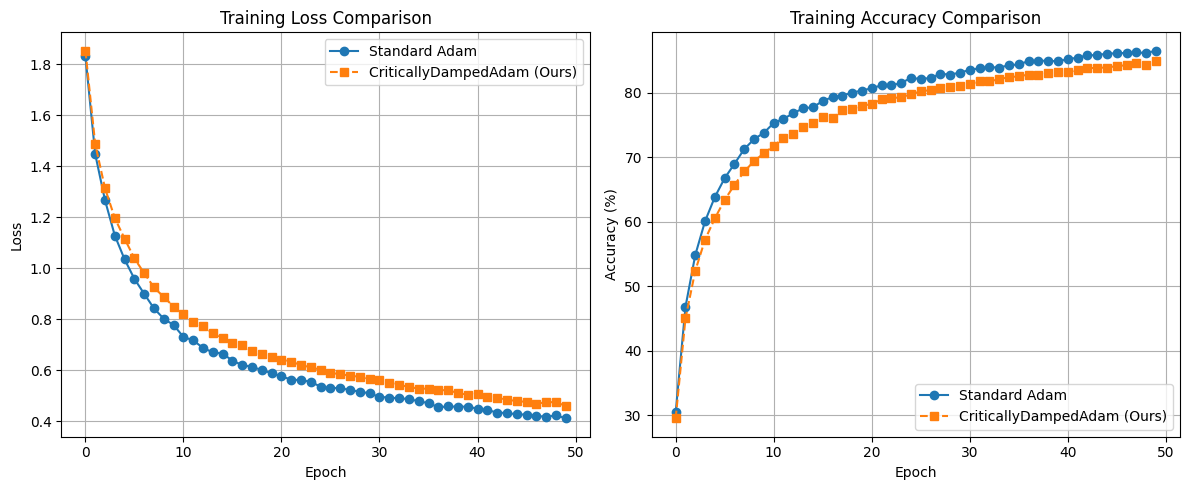

In [21]:
if __name__ == "__main__":
    train_and_plot()